# Probability Distributions in Machine Learning

A **probability distribution** describes how probability is spread over the values of a random variable.
ML models rely on specific distributions to model data, define likelihoods, set priors, and derive loss functions.

---

## Discrete Distributions

A **discrete distribution** assigns probability to a countable set of outcomes via a **Probability Mass Function (PMF)**: $P(X = x)$.

| Distribution | Notation | PMF $P(X=k)$ | Mean | Variance | ML Use-case |
|---|---|---|---|---|---|
| **Bernoulli** | $\text{Bern}(p)$ | $p^k(1-p)^{1-k},\; k\in\{0,1\}$ | $p$ | $p(1-p)$ | Binary classification output, coin flip |
| **Binomial** | $\text{Bin}(n,p)$ | $\binom{n}{k}p^k(1-p)^{n-k}$ | $np$ | $np(1-p)$ | Count of successes in $n$ trials |
| **Categorical** | $\text{Cat}(\mathbf{p})$ | $p_k,\; k\in\{1,\ldots,K\}$ | — | — | Multi-class classification (softmax output) |
| **Multinomial** | $\text{Mult}(n,\mathbf{p})$ | $\frac{n!}{k_1!\cdots k_K!}\prod p_i^{k_i}$ | $np_i$ | $np_i(1-p_i)$ | Word counts in NLP, multi-class counts |
| **Poisson** | $\text{Pois}(\lambda)$ | $\frac{\lambda^k e^{-\lambda}}{k!}$ | $\lambda$ | $\lambda$ | Event counts, rare events, NLP token frequencies |
| **Geometric** | $\text{Geom}(p)$ | $(1-p)^{k-1}p$ | $\frac{1}{p}$ | $\frac{1-p}{p^2}$ | Number of trials until first success |
| **Negative Binomial** | $\text{NB}(r,p)$ | $\binom{k+r-1}{k}(1-p)^r p^k$ | $\frac{pr}{1-p}$ | $\frac{pr}{(1-p)^2}$ | Overdispersed count data (NLP, genomics) |

---

## Continuous Distributions

A **continuous distribution** assigns probability via a **Probability Density Function (PDF)**: $p(x)$, where $P(a \le X \le b)=\int_a^b p(x)\,dx$.

| Distribution | Notation | PDF $p(x)$ | Mean | Variance | ML Use-case |
|---|---|---|---|---|---|
| **Normal (Gaussian)** | $\mathcal{N}(\mu,\sigma^2)$ | $\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ | $\mu$ | $\sigma^2$ | Regression targets, noise model, Gaussian priors, latent variables |
| **Multivariate Normal** | $\mathcal{N}(\boldsymbol{\mu},\boldsymbol{\Sigma})$ | $\frac{1}{(2\pi)^{d/2}\lVert\boldsymbol{\Sigma}\rVert^{1/2}}e^{-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})}$ | $\boldsymbol{\mu}$ | $\boldsymbol{\Sigma}$ | GMM, LDA, VAE latent space, Gaussian processes |
| **Uniform** | $\mathcal{U}(a,b)$ | $\frac{1}{b-a}$ | $\frac{a+b}{2}$ | $\frac{(b-a)^2}{12}$ | Weight initialisation, random sampling, non-informative prior |
| **Exponential** | $\text{Exp}(\lambda)$ | $\lambda e^{-\lambda x},\; x\ge 0$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ | Time-to-event, survival analysis, regularisation |
| **Beta** | $\text{Beta}(\alpha,\beta)$ | $\frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$ | $\frac{\alpha}{\alpha+\beta}$ | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ | Prior for Bernoulli/Binomial $p$, Bayesian ML |
| **Dirichlet** | $\text{Dir}(\boldsymbol{\alpha})$ | $\frac{1}{B(\boldsymbol{\alpha})}\prod x_i^{\alpha_i-1}$ | $\frac{\alpha_i}{\alpha_0}$ | — | Prior for Categorical/Multinomial, LDA topic models |
| **Gamma** | $\text{Gamma}(\alpha,\beta)$ | $\frac{\beta^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}$ | $\frac{\alpha}{\beta}$ | $\frac{\alpha}{\beta^2}$ | Prior for precision/rate, Bayesian models |
| **Student's t** | $t_\nu(\mu,\sigma^2)$ | $\propto\left(1+\frac{(x-\mu)^2}{\nu\sigma^2}\right)^{-\frac{\nu+1}{2}}$ | $\mu\;(\nu>1)$ | $\frac{\nu\sigma^2}{\nu-2}\;(\nu>2)$ | Robust regression, heavy-tailed noise |
| **Laplace** | $\text{Laplace}(\mu,b)$ | $\frac{1}{2b}e^{-\frac{\lvert x-\mu \rvert}{b}}$ | $\mu$ | $2b^2$ | L1 / Lasso prior on weights, sparse models |
| **Logistic** | $\text{Logistic}(\mu,s)$ | $\frac{e^{-(x-\mu)/s}}{s(1+e^{-(x-\mu)/s})^2}$ | $\mu$ | $\frac{\pi^2 s^2}{3}$ | Logistic regression, sigmoid link function |

---

> **Key insight:** Choosing the right distribution is a modelling decision — it encodes your assumptions about the data, noise, and parameters.

---

## Plots

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        10,
})

### Discrete Distributions

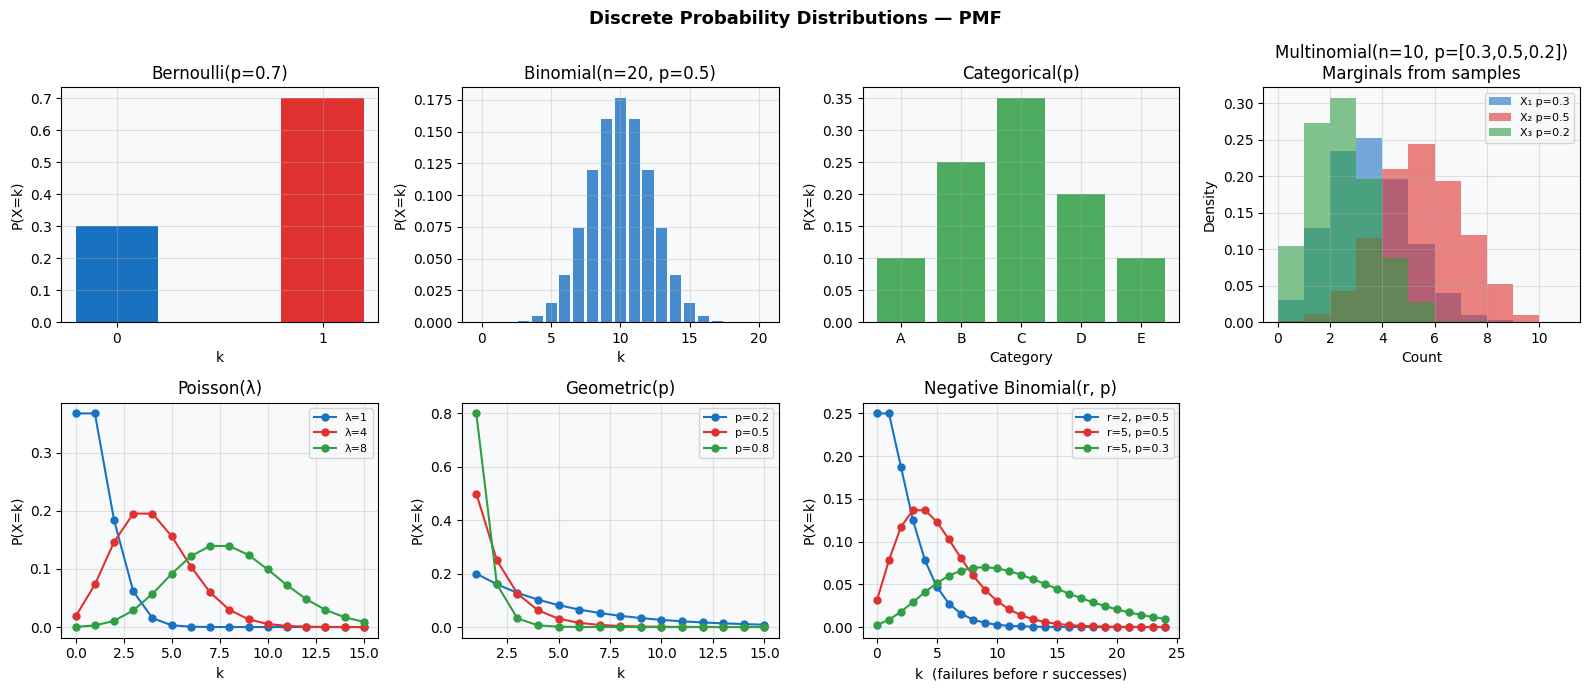

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

# --- Bernoulli ---
ax = axes[0]
p = 0.7
ax.bar([0, 1], [1 - p, p], color=['#1971c2', '#e03131'], width=0.4)
ax.set_title(f'Bernoulli(p={p})')
ax.set_xticks([0, 1])
ax.set_xlabel('k')
ax.set_ylabel('P(X=k)')

# --- Binomial ---
ax = axes[1]
n, p = 20, 0.5
k = np.arange(0, n + 1)
ax.bar(k, stats.binom.pmf(k, n, p), color='#1971c2', alpha=0.8)
ax.set_title(f'Binomial(n={n}, p={p})')
ax.set_xlabel('k')
ax.set_ylabel('P(X=k)')

# --- Categorical ---
ax = axes[2]
probs = [0.10, 0.25, 0.35, 0.20, 0.10]
cats = ['A', 'B', 'C', 'D', 'E']
ax.bar(cats, probs, color='#2f9e44', alpha=0.85)
ax.set_title('Categorical(p)')
ax.set_xlabel('Category')
ax.set_ylabel('P(X=k)')

# --- Multinomial (marginals from samples) ---
ax = axes[3]
rng = np.random.default_rng(42)
samples = rng.multinomial(10, [0.3, 0.5, 0.2], size=2000)
bins = range(12)
ax.hist(samples[:, 0], bins=bins, alpha=0.6, color='#1971c2', label='X₁ p=0.3', density=True)
ax.hist(samples[:, 1], bins=bins, alpha=0.6, color='#e03131', label='X₂ p=0.5', density=True)
ax.hist(samples[:, 2], bins=bins, alpha=0.6, color='#2f9e44', label='X₃ p=0.2', density=True)
ax.set_title('Multinomial(n=10, p=[0.3,0.5,0.2])\nMarginals from samples')
ax.set_xlabel('Count')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# --- Poisson ---
ax = axes[4]
k = np.arange(0, 16)
for lam, col in [(1, '#1971c2'), (4, '#e03131'), (8, '#2f9e44')]:
    ax.plot(k, stats.poisson.pmf(k, lam), 'o-', color=col, lw=1.5, ms=5, label=f'λ={lam}')
ax.set_title('Poisson(λ)')
ax.set_xlabel('k')
ax.set_ylabel('P(X=k)')
ax.legend(fontsize=8)

# --- Geometric ---
ax = axes[5]
k = np.arange(1, 16)
for p, col in [(0.2, '#1971c2'), (0.5, '#e03131'), (0.8, '#2f9e44')]:
    ax.plot(k, stats.geom.pmf(k, p), 'o-', color=col, lw=1.5, ms=5, label=f'p={p}')
ax.set_title('Geometric(p)')
ax.set_xlabel('k')
ax.set_ylabel('P(X=k)')
ax.legend(fontsize=8)

# --- Negative Binomial ---
ax = axes[6]
k = np.arange(0, 25)
for r, p, col in [(2, 0.5, '#1971c2'), (5, 0.5, '#e03131'), (5, 0.3, '#2f9e44')]:
    ax.plot(k, stats.nbinom.pmf(k, r, p), 'o-', color=col, lw=1.5, ms=5, label=f'r={r}, p={p}')
ax.set_title('Negative Binomial(r, p)')
ax.set_xlabel('k  (failures before r successes)')
ax.set_ylabel('P(X=k)')
ax.legend(fontsize=8)

axes[7].set_visible(False)

plt.suptitle('Discrete Probability Distributions — PMF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Continuous Distributions (Univariate)

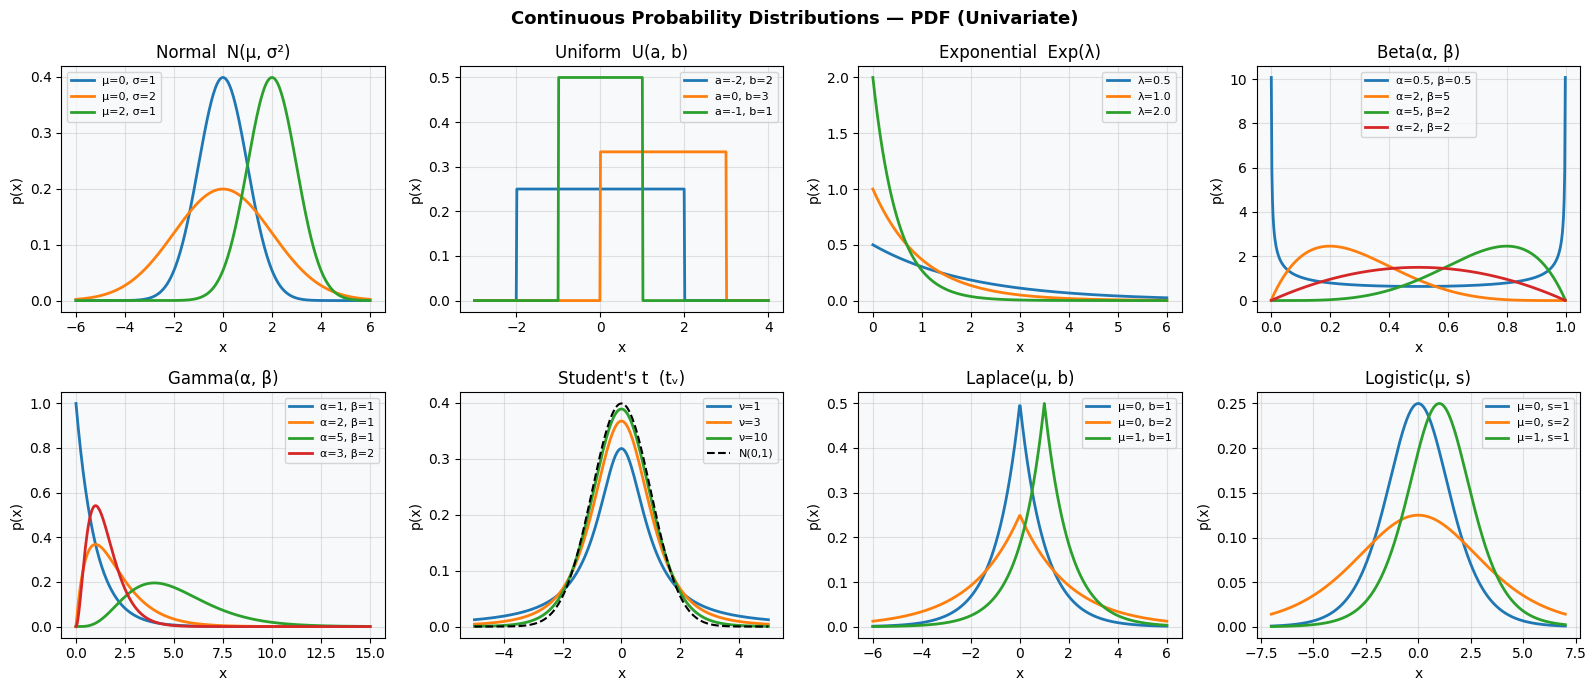

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

# --- Normal ---
ax = axes[0]
x = np.linspace(-6, 6, 500)
for mu, sigma, col in [(0, 1, '#1971c2'), (0, 2, '#e03131'), (2, 1, '#2f9e44')]:
    ax.plot(x, stats.norm.pdf(x, mu, sigma), lw=2, label=f'μ={mu}, σ={sigma}')
ax.set_title('Normal  N(μ, σ²)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Uniform ---
ax = axes[1]
x = np.linspace(-3, 4, 500)
for a, b, col in [(-2, 2, '#1971c2'), (0, 3, '#e03131'), (-1, 1, '#2f9e44')]:
    ax.plot(x, stats.uniform.pdf(x, a, b - a), lw=2, label=f'a={a}, b={b}')
ax.set_title('Uniform  U(a, b)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Exponential ---
ax = axes[2]
x = np.linspace(0, 6, 500)
for lam, col in [(0.5, '#1971c2'), (1.0, '#e03131'), (2.0, '#2f9e44')]:
    ax.plot(x, stats.expon.pdf(x, scale=1 / lam), lw=2, label=f'λ={lam}')
ax.set_title('Exponential  Exp(λ)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Beta ---
ax = axes[3]
x = np.linspace(0.001, 0.999, 500)
for a, b, col in [(0.5, 0.5, '#1971c2'), (2, 5, '#e03131'), (5, 2, '#2f9e44'), (2, 2, '#f08c00')]:
    ax.plot(x, stats.beta.pdf(x, a, b), lw=2, label=f'α={a}, β={b}')
ax.set_title('Beta(α, β)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Gamma ---
ax = axes[4]
x = np.linspace(0.001, 15, 500)
for a, b, col in [(1, 1, '#1971c2'), (2, 1, '#e03131'), (5, 1, '#2f9e44'), (3, 2, '#f08c00')]:
    ax.plot(x, stats.gamma.pdf(x, a, scale=1 / b), lw=2, label=f'α={a}, β={b}')
ax.set_title('Gamma(α, β)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Student's t ---
ax = axes[5]
x = np.linspace(-5, 5, 500)
for nu, col in [(1, '#1971c2'), (3, '#e03131'), (10, '#2f9e44')]:
    ax.plot(x, stats.t.pdf(x, nu), lw=2, label=f'ν={nu}')
ax.plot(x, stats.norm.pdf(x), lw=1.5, ls='--', color='black', label='N(0,1)')
ax.set_title("Student's t  (tᵥ)")
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Laplace ---
ax = axes[6]
x = np.linspace(-6, 6, 500)
for mu, b, col in [(0, 1, '#1971c2'), (0, 2, '#e03131'), (1, 1, '#2f9e44')]:
    ax.plot(x, stats.laplace.pdf(x, mu, b), lw=2, label=f'μ={mu}, b={b}')
ax.set_title('Laplace(μ, b)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

# --- Logistic ---
ax = axes[7]
x = np.linspace(-7, 7, 500)
for mu, s, col in [(0, 1, '#1971c2'), (0, 2, '#e03131'), (1, 1, '#2f9e44')]:
    ax.plot(x, stats.logistic.pdf(x, mu, s), lw=2, label=f'μ={mu}, s={s}')
ax.set_title('Logistic(μ, s)')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.legend(fontsize=8)

plt.suptitle('Continuous Probability Distributions — PDF (Univariate)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Multivariate Distributions (2D)

- **Multivariate Normal**: shown as 2D contour plots for different mean vectors and covariance matrices.
- **Dirichlet**: defined on the 2-simplex ($p_1 + p_2 + p_3 = 1$); contours are shown in the $(p_1, p_2)$ plane with $p_3 = 1 - p_1 - p_2$.

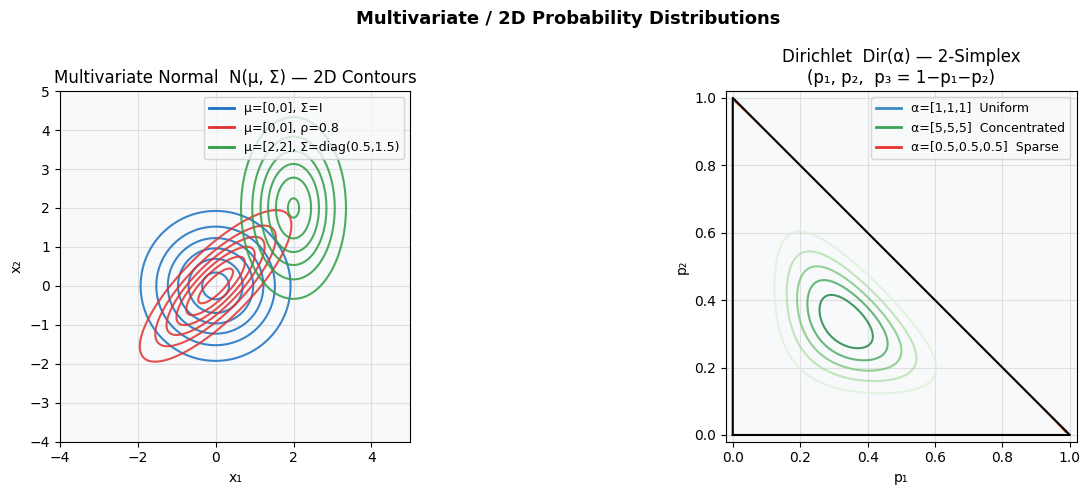

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Multivariate Normal ──────────────────────────────────────────────────────
ax = axes[0]
x1 = np.linspace(-4, 5, 250)
x2 = np.linspace(-4, 5, 250)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))

configs_mvn = [
    (dict(mean=[0, 0], cov=[[1, 0],   [0, 1]]),   '#1971c2', 'μ=[0,0], Σ=I'),
    (dict(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]), '#e03131', 'μ=[0,0], ρ=0.8'),
    (dict(mean=[2, 2], cov=[[0.5, 0], [0, 1.5]]), '#2f9e44', 'μ=[2,2], Σ=diag(0.5,1.5)'),
]
for cfg, col, lbl in configs_mvn:
    rv = stats.multivariate_normal(mean=cfg['mean'], cov=cfg['cov'])
    ax.contour(X1, X2, rv.pdf(pos), levels=6, colors=[col], alpha=0.85)
    ax.plot([], [], color=col, lw=2, label=lbl)

ax.set_title('Multivariate Normal  N(μ, Σ) — 2D Contours')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# ── Dirichlet on the 2-simplex ───────────────────────────────────────────────
ax = axes[1]
n = 200
p1 = np.linspace(0.005, 0.990, n)
p2 = np.linspace(0.005, 0.990, n)
P1, P2 = np.meshgrid(p1, p2)
P3 = 1 - P1 - P2

# mask points outside the simplex (P3 must be > 0)
valid = P3 > 0

configs_dir = [
    ([1,   1,   1],   'Blues',   'α=[1,1,1]  Uniform'),
    ([5,   5,   5],   'Greens',  'α=[5,5,5]  Concentrated'),
    ([0.5, 0.5, 0.5], 'Reds',    'α=[0.5,0.5,0.5]  Sparse'),
]
for alpha_dir, cmap, lbl in configs_dir:
    Z = np.full((n, n), np.nan)
    pts = np.array([P1[valid], P2[valid], P3[valid]])   # shape (3, M), all valid
    Z[valid] = stats.dirichlet.pdf(pts, alpha_dir)
    ax.contour(P1, P2, Z, levels=5, cmap=cmap, alpha=0.75)
    ax.plot([], [], color=plt.get_cmap(cmap)(0.65), lw=2, label=lbl)

# Draw simplex boundary
ax.plot([0, 1, 0, 0], [0, 0, 1, 0], 'k-', lw=1.5)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_title('Dirichlet  Dir(α) — 2-Simplex\n(p₁, p₂,  p₃ = 1−p₁−p₂)')
ax.set_xlabel('p₁')
ax.set_ylabel('p₂')
ax.legend(fontsize=9)
ax.set_aspect('equal')

plt.suptitle('Multivariate / 2D Probability Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Identifying Distributions from Data

Given a real dataset, choosing the right distribution is a modelling decision.
The workflow below guides you from raw data to a fitted, validated distribution.

---

### Step 1 — Know your variable type

| Variable type | Candidates |
|---|---|
| Binary outcome (0/1) | Bernoulli, Binomial |
| Non-negative integer counts | Poisson, Negative Binomial |
| Proportion / probability (0–1) | Beta |
| Continuous, symmetric, bell-shaped | Normal |
| Continuous, right-skewed, positive | Gamma, Exponential, Log-Normal |
| Bounded range $[a, b]$ | Uniform, Beta (rescaled) |
| Heavy tails / many outliers | Student's t, Laplace |
| Multi-class probability vector | Dirichlet |

---

### Step 2 — Summary statistics as clues

| Observation | Implication |
|---|---|
| Mean ≈ Median ≈ Mode | Symmetric (Normal, Uniform) |
| Mean > Median | Right skew (Gamma, Exponential) |
| Mean ≈ Variance | Poisson |
| Variance > Mean | Negative Binomial (overdispersion) |
| Variance < Mean | Binomial (underdispersion) |
| High kurtosis (heavy tails) | Student's t, Laplace |

---

### Step 3 — Visual checks

| Plot | What to look for |
|---|---|
| **Histogram / KDE** | Shape: symmetric, skewed, bimodal, bounded |
| **Box plot** | Skew direction, outlier frequency |
| **Q-Q plot** | Points on the diagonal → data matches that distribution |
| **Log-scale histogram** | Straight line on log-y → Exponential tail |

---

### Step 4 — Fit & test

1. Fit candidate distributions with `scipy.stats.<dist>.fit(data)` (MLE).
2. Run a **KS test** (`kstest`) — $p > 0.05$ means we cannot reject the fit.
3. Compare multiple candidates via **AIC / BIC** (lower = better).
4. Validate visually with a **Q-Q plot**.

---

### Step 5 — Domain knowledge (always the strongest signal)

| Domain context | Distribution |
|---|---|
| Click-through / conversion rates | Beta |
| Word / token counts in documents | Poisson, Negative Binomial |
| Neural network weight initialization | Normal |
| Time between independent events | Exponential |
| Regression residuals | Normal (by assumption) |
| Number of failures before success | Geometric, Negative Binomial |

### Worked Example — Fit & Validate on Synthetic Data

We generate data from a **Gamma** distribution and demonstrate the full identification workflow:
histogram → summary stats → fit three candidates → KS test → Q-Q plots.

Step 2 — Summary Statistics


,N,Mean,Median,Std,Variance,Skewness,Kurtosis
0,500,2.8769,2.5183,1.6349,2.673,1.2399,2.0901


  Mean/Variance ratio: 1.076  (≈1 → Poisson; >1 → Gamma/Exp likely)

Step 4 — Goodness-of-Fit (KS test + AIC):


,Distribution,KS stat,KS p-value,AIC,Reject (α=0.05)
2,Gamma,0.0238,0.9326,1782.08,False
0,Normal,0.0930,0.0003,1914.54,True
1,Exponential,0.2114,0.0000,1999.22,True


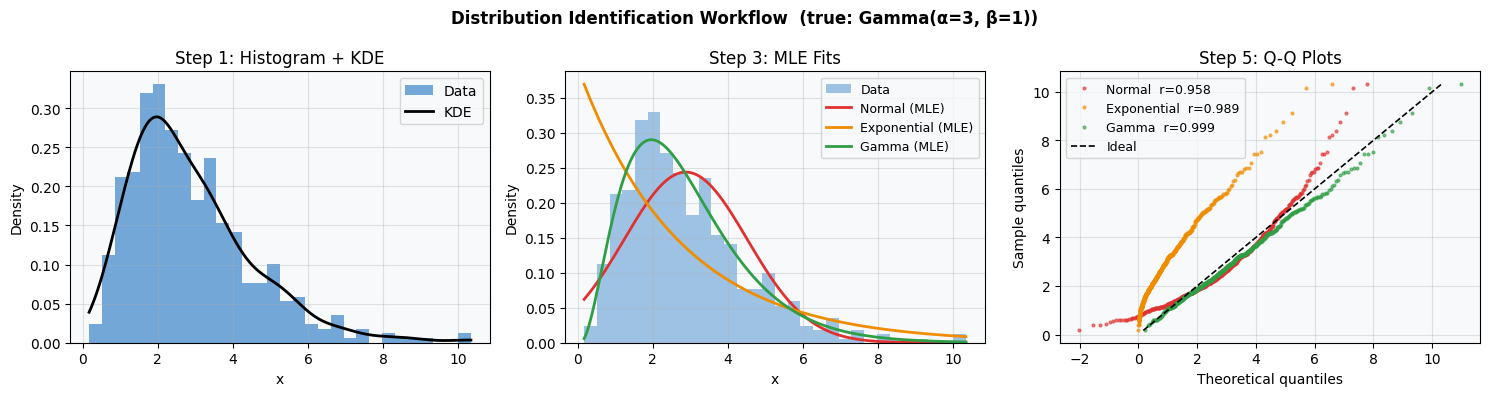

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

rng = np.random.default_rng(0)

# ── Generate data from Gamma(α=3, β=1) ──────────────────────────────────────
true_dist = stats.gamma(a=3, scale=1.0)
data = true_dist.rvs(size=500, random_state=rng)

# ── Step 1: histogram + KDE ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(data, bins=30, density=True, color='#1971c2', alpha=0.6, label='Data')
xg = np.linspace(data.min(), data.max(), 300)
kde = stats.gaussian_kde(data)
ax.plot(xg, kde(xg), color='black', lw=2, label='KDE')
ax.set_title('Step 1: Histogram + KDE')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()

# ── Step 2: summary stats ────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'N':        len(data),
    'Mean':     data.mean(),
    'Median':   np.median(data),
    'Std':      data.std(),
    'Variance': data.var(),
    'Skewness': stats.skew(data),
    'Kurtosis': stats.kurtosis(data),
}]).round(4)
print("Step 2 — Summary Statistics")
display(summary)
print(f"  Mean/Variance ratio: {data.mean()/data.var():.3f}  "
      f"(≈1 → Poisson; >1 → Gamma/Exp likely)")

# ── Step 3: fit candidate distributions ─────────────────────────────────────
candidates = {
    'Normal':      stats.norm,
    'Exponential': stats.expon,
    'Gamma':       stats.gamma,
}

ax = axes[1]
ax.hist(data, bins=30, density=True, color='#1971c2', alpha=0.4, label='Data')
colors = {'Normal': '#e03131', 'Exponential': '#f08c00', 'Gamma': '#2f9e44'}
fit_params = {}

for name, dist in candidates.items():
    params = dist.fit(data)
    fit_params[name] = params
    ax.plot(xg, dist.pdf(xg, *params), lw=2, color=colors[name], label=f'{name} (MLE)')

ax.set_title('Step 3: MLE Fits')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# ── Step 4: KS test + AIC ────────────────────────────────────────────────────
rows = []
for name, dist in candidates.items():
    params = fit_params[name]
    ks_stat, ks_p = stats.kstest(data, dist.cdf, args=params)
    log_lik = np.sum(dist.logpdf(data, *params))
    k = len(params)
    aic = 2 * k - 2 * log_lik
    rows.append({'Distribution': name, 'KS stat': round(ks_stat, 4),
                 'KS p-value': round(ks_p, 4), 'AIC': round(aic, 2),
                 'Reject (α=0.05)': ks_p < 0.05})

df_fit = pd.DataFrame(rows).sort_values('AIC')
print("\nStep 4 — Goodness-of-Fit (KS test + AIC):")
display(df_fit)

# ── Step 5: Q-Q plots ────────────────────────────────────────────────────────
ax = axes[2]
for name, dist in candidates.items():
    params = fit_params[name]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist=dist, sparams=params[:-2] if name != 'Normal' else params)
    ax.plot(osm, osr, 'o', ms=2, color=colors[name], alpha=0.6, label=f'{name}  r={r:.3f}')

ax.plot([data.min(), data.max()], [data.min(), data.max()], 'k--', lw=1.2, label='Ideal')
ax.set_title('Step 5: Q-Q Plots')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.legend(fontsize=9)

plt.suptitle('Distribution Identification Workflow  (true: Gamma(α=3, β=1))',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()